<a href="https://colab.research.google.com/github/Tanbir-Hasan-247/Colab-file/blob/main/41230100901_Tanbir_Hasan_10(A)_Lab1Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Homework Dataset

In [ ]:
import pandas as pd
import numpy as np
# Load dataset from a URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Define column names
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
           "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

# Read the dataset
df = pd.read_csv(url, names=columns)

df["Outcome"] = df["Outcome"].replace({0: "No Diabetes", 1: "Diabetes"})


# Display first 5 rows
print("First 5 Rows of Dataset:\n", df.head())


First 5 Rows of Dataset:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age      Outcome  
0                     0.627   50     Diabetes  
1                     0.351   31  No Diabetes  
2                     0.672   32     Diabetes  
3                     0.167   21  No Diabetes  
4                     2.288   33     Diabetes  


###Home-Work Tasks

📌 Check dataset info, statistics, and missing values

📌 Some columns contain 0 as missing values (e.g., Glucose, BloodPressure, BMI). So, Replace 0 values with the median (except for Pregnancies and Outcome)

📌 Find and remove duplicate rows

📌 Normalize Glucose, BMI, and Age between 0 and 1

📌 Encoding Categorical Variables (e.g., Outcome)

📌 Filter patients with Outcome = 1 (diabetes) and Age > 40



📌 **Visualize by Plotting the Diabetes Dataset:**
1. **Histogram of Blood Glucose Levels**

    🔹 Why?
    
    To see the distribution of glucose levels among patients.

    🔹 Plot Type: Histogram
2. **Box Plot of BMI by Diabetes Outcome**

    🔹 Why?
    
    To compare BMI values between diabetic and non-diabetic patients.

    🔹 Plot Type: Box Plot
3. **Correlation Heatmap**

    🔹 Why?
    
    To analyze how features are correlated with diabetes.

    🔹 Plot Type: Heatmap
4. **Age Distribution of Diabetic vs. Non-Diabetic Patients**

    🔹 Why?
    
    To check if age is a major factor for diabetes.

    🔹 Plot Type: KDE (Kernel Density Estimate) Plot
5. **Scatter Plot of Glucose vs. BMI**

    🔹 Why?
    
    To visualize the relationship between glucose levels and BMI.

    🔹 Plot Type: Scatter Plot

**📌 Check dataset info, statistics, and missing values**

In [ ]:
df.info()
df.describe()
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[cols] = df[cols].replace(0, np.nan)
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    object 
dtypes: float64(2), int64(6), object(1)
memory usage: 54.1+ KB


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**📌 Some columns contain 0 as missing values (e.g., Glucose, BloodPressure, BMI). So, Replace 0 values with the median (except for Pregnancies and Outcome)**

In [ ]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
  median = df[col].median()
  df[col] = df[col].fillna(median)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,Diabetes
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,No Diabetes
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,Diabetes
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,No Diabetes
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,Diabetes


**📌 Find and remove duplicate rows**

In [ ]:
df = df.drop_duplicates()

**📌 Normalize Glucose, BMI, and Age between 0 and 1**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

columns_to_scale = ['Glucose','BMI','Age']
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print("\nDataset after Scaling:\n", df_scaled.head())


Dataset after Scaling:
    Pregnancies   Glucose  BloodPressure  SkinThickness  Insulin       BMI  \
0            6  0.670968           72.0           35.0    125.0  0.314928   
1            1  0.264516           66.0           29.0    125.0  0.171779   
2            8  0.896774           64.0           29.0    125.0  0.104294   
3            1  0.290323           66.0           23.0     94.0  0.202454   
4            0  0.600000           40.0           35.0    168.0  0.509202   

   DiabetesPedigreeFunction       Age      Outcome  
0                     0.627  0.483333     Diabetes  
1                     0.351  0.166667  No Diabetes  
2                     0.672  0.183333     Diabetes  
3                     0.167  0.000000  No Diabetes  
4                     2.288  0.200000     Diabetes  


**📌 Encoding Categorical Variables (e.g., Outcome)**

In [ ]:
order = {"Diabetes":1,"No Diabetes":0}

df["Outcome"] = df["Outcome"].map(order).astype(int)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


**📌 Filter patients with Outcome = 1 (diabetes) and Age > 40**

In [ ]:
Diabetes = df[(df['Outcome']==1) & (df['Age']>40)]
Diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,29.0,125.0,32.3,0.232,54,1
13,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1
14,5,166.0,72.0,19.0,175.0,25.8,0.587,51,1


**📌 Visualize by Plotting the Diabetes Dataset:**

**1. Histogram of Blood Glucose Levels**

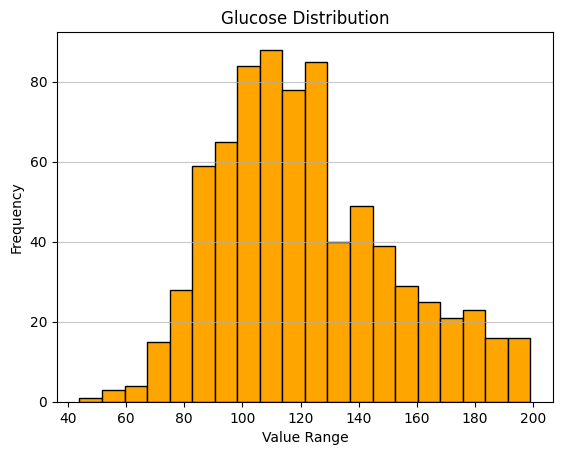

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["Glucose"], bins=20, color='orange', edgecolor='black')
plt.title('Glucose Distribution')
plt.xlabel('Value Range')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.7)
plt.show()

**2. Box Plot of BMI by Diabetes Outcome**

<Figure size 600x600 with 0 Axes>

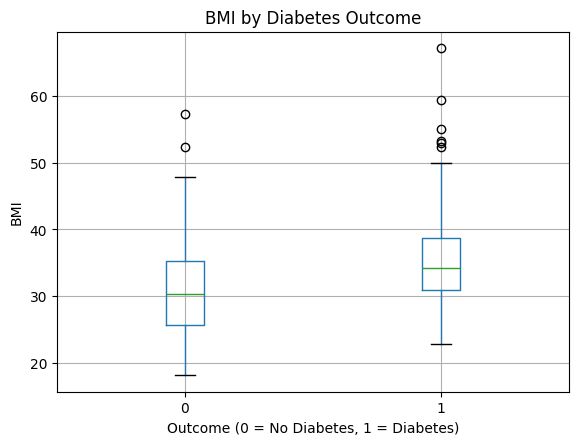

In [ ]:
plt.figure(figsize=(6,6))
df.boxplot(column="BMI", by="Outcome")
plt.title("BMI by Diabetes Outcome")
plt.suptitle("")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("BMI")
plt.show()

**3.Correlation Heatmap**

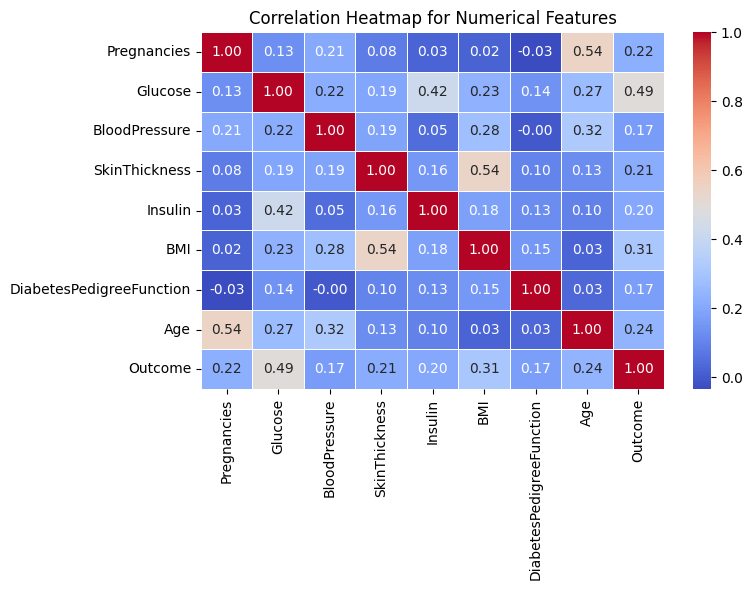

In [ ]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()

**4. Age Distribution of Diabetic vs. Non-Diabetic Patients**

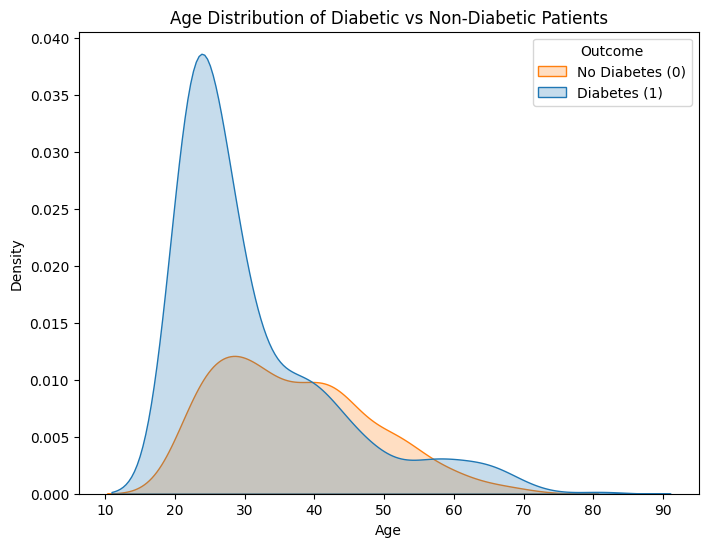

In [ ]:
plt.figure(figsize=(8,6))

sns.kdeplot(data=df, x="Age", hue="Outcome", fill=True)

plt.title("Age Distribution of Diabetic vs Non-Diabetic Patients")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend(title="Outcome", labels=["No Diabetes (0)", "Diabetes (1)"])

plt.show()

**5. Scatter Plot of Glucose vs. BMI**

/tmp/ipython-input-3246203568.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


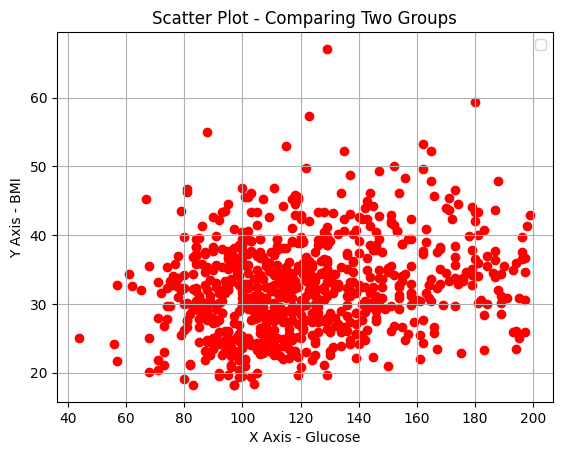

In [ ]:
plt.scatter(df["Glucose"], df['BMI'], color='red', marker='o')

plt.title('Scatter Plot - Comparing Two Groups')
plt.xlabel('X Axis - Glucose')
plt.ylabel('Y Axis - BMI')
plt.legend()
plt.grid(True)
plt.show()